In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data_processing import procesar_y_guardar_datos

raw = "../datos/raw/ala_2d_completo.csv"
processed = "../datos/processed/ala_2d_processed_completo.csv"
toy = "../datos/toy/ala_2d_toy.csv"

df_limpio = procesar_y_guardar_datos(raw, processed, toy)

,x,y,U_x,U_y,nut,implicit_distance
count,163364.000000,163364.000000,163364.000000,163364.000000,1.633640e+05,163364.000000
mean,-0.174540,0.004996,0.220238,0.239968,2.395317e-04,-0.242606
std,0.231531,0.202234,0.549602,0.265404,6.636849e-04,0.490733
min,-1.000000,-1.000000,-1.000000,-1.000000,0.000000e+00,-3.566965
25%,-0.323482,-0.007352,-0.169726,0.182578,4.295808e-12,-0.212833
50%,-0.250616,0.001725,0.491158,0.254282,1.011826e-09,-0.015299
75%,-0.019757,0.024342,0.634139,0.323915,1.547588e-05,-0.000653
max,1.000000,1.000000,1.000000,1.000000,4.419085e-03,-0.000000


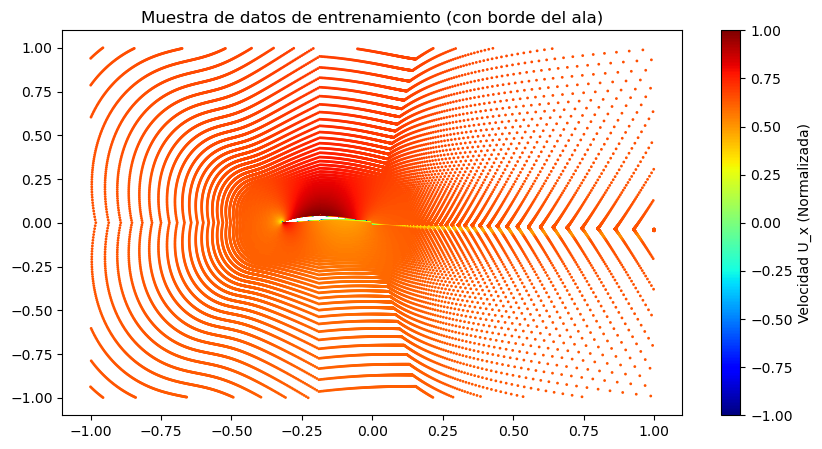

In [14]:
display(df_limpio.describe())

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.scatter(df_limpio['x'], df_limpio['y'], c=df_limpio['U_x'], cmap='jet', s=1)
plt.colorbar(label='Velocidad U_x (Normalizada)')
plt.title("Muestra de datos de entrenamiento (con borde del ala)")
plt.show()

In [2]:
import torch
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.model import InversePINN

#Se pone a prueba el modelo de la PINN del archivo model.py

modelo_prueba = InversePINN(num_capas=4, num_neuronas=64)
print("Modelo instanciado exitosamente.\n")

#Se crean datos de prueba con 5 puntos al azar para "x" e "y", con requires_grad=true

x_falso = torch.rand((5, 1), requires_grad=True)
y_falso = torch.rand((5, 1), requires_grad=True)

print(f"Dimensión de entrada x: {x_falso.shape} (Debe ser [5, 1])")
print(f"Dimensión de entrada y: {y_falso.shape} (Debe ser [5, 1])\n")

#Se realiza el forward pass
ux_pred, uy_pred = modelo_prueba(x_falso, y_falso)

#Se validan las salidas
print("Predicción:")
print(f"Dimensión de ux_pred: {ux_pred.shape} -> ¿Es [5, 1]? {'Sí' if ux_pred.shape == (5,1) else 'No'}")
print(f"Dimensión de uy_pred: {uy_pred.shape} -> ¿Es [5, 1]? {'Sí' if uy_pred.shape == (5,1) else 'No'}\n")

#Se valida la viscosidad efectiva
viscosidad_inicial = modelo_prueba.obtener_viscosidad().item()
print("Parámetro Físico")
print(f"Valor inicial de theta_nu (pesos): {modelo_prueba.visc.item():.4f}")
print(f"Viscosidad real transformada: {viscosidad_inicial:.6f} -> ¿Es aprox 0.01? {'Sí' if abs(viscosidad_inicial - 0.01) < 1e-4 else 'No'}")

Modelo instanciado exitosamente.

Dimensión de entrada x: torch.Size([5, 1]) (Debe ser [5, 1])
Dimensión de entrada y: torch.Size([5, 1]) (Debe ser [5, 1])

Predicción:
Dimensión de ux_pred: torch.Size([5, 1]) -> ¿Es [5, 1]? Sí
Dimensión de uy_pred: torch.Size([5, 1]) -> ¿Es [5, 1]? Sí

Parámetro Físico
Valor inicial de theta_nu (pesos): -4.6052
Viscosidad real transformada: 0.010000 -> ¿Es aprox 0.01? Sí
